Fit comparison using LHAPDF

In [2]:
import os
import sys
import subprocess

# set path to for_lhapdf
for_lhapdf_path = os.path.expanduser("/mnt/c/Users/daksh/nnpdf_reports/for_lhapdf")
if for_lhapdf_path not in sys.path:
    sys.path.insert(0, for_lhapdf_path)

# define a helper that runs the command and stays quiet
def run_cmd(cmd_list, comments=False):
    # This runs the command in the background, 
    # sends logs to devnull, and waits for it to finish.
    if comments:
        subprocess.run(cmd_list)
    else:
        subprocess.run(cmd_list, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

In [3]:
# delete the already (if) present Basic_runcard_bayesian_100 
lhapdf_path = "/home/daksh/anaconda3/envs/environment_nnpdf/share/LHAPDF"
print("Removing pre-existing Bayesian directory from LHAPDF")
run_cmd(["rm", "-r", f"{lhapdf_path}/Basic_runcard_bayesian_100"], comments=True)

Removing pre-existing Bayesian directory from LHAPDF


rm: cannot remove '/home/daksh/anaconda3/envs/environment_nnpdf/share/LHAPDF/Basic_runcard_bayesian_100': No such file or directory


In [ ]:
import lhapdf
import numpy as np
import matplotlib.pyplot as plt

# move the fit to lhapdf directory
for_lhapdf_path = "/mnt/c/Users/daksh/nnpdf_reports/for_lhapdf"
lhapdf_path = "/home/daksh/anaconda3/envs/environment_nnpdf/share/LHAPDF"
nnpdf_results_path = "/home/daksh/anaconda3/envs/environment_nnpdf/share/NNPDF/results"

# CHANGE here: the fit you want to rum comparison for
p_value = '0.5'
replica = '300'
keywords = None #'dropout'
fit = f'Basic_runcard_bayesian_100_p{p_value}'

print(f"Moving {fit} to LHAPDF")
run_cmd(["cp", "-r", f"{for_lhapdf_path}/{fit}", lhapdf_path], comments=True)

# rename the fit 
new_name = f"Basic_runcard_bayesian_100"
print(f"Renaming {fit} to {new_name}")
os.chdir(f"{lhapdf_path}")
run_cmd(["mv", f"{lhapdf_path}/{fit}", f"{new_name}"], comments=True)

# Load PDF sets (returns a list: idx 0: central, 1+ :replicas)
new_fit = lhapdf.mkPDFs(f"{new_name}")
ref_fit = lhapdf.mkPDFs("Basic_runcard_normal_100")

Moving Basic_runcard_bayesian_100_p0.5 to LHAPDF
Renaming Basic_runcard_bayesian_100_p0.5 to Basic_runcard_bayesian_100
LHAPDF 6.5.5 loading all 301 PDFs in set Basic_runcard_bayesian_100
Basic_runcard_bayesian_100, version 1; 301 PDF members
LHAPDF 6.5.5 loading all 51 PDFs in set Basic_runcard_normal_100
Basic_runcard_normal_100, version 1; 51 PDF members


In [22]:
 
p_value = '0.01'
replica = '20'
keywords = 'dropout'
new_fit = lhapdf.mkPDFs("mc-1rep-samples_bayes")
ref_fit = lhapdf.mkPDFs("mc-1rep-samples")



LHAPDF 6.5.5 loading all 21 PDFs in set mc-1rep-samples_bayes
mc-1rep-samples_bayes, version 1; 21 PDF members
LHAPDF 6.5.5 loading all 21 PDFs in set mc-1rep-samples
mc-1rep-samples, version 1; 21 PDF members


In [23]:
# Kinematics and flavor selection
Q = 1.65      # Factorization scale in GeV
x_vals = np.logspace(-5, -0.001, 100)
pid = 21       # 21 = Gluon, 2 = up, 1 = down, etc.

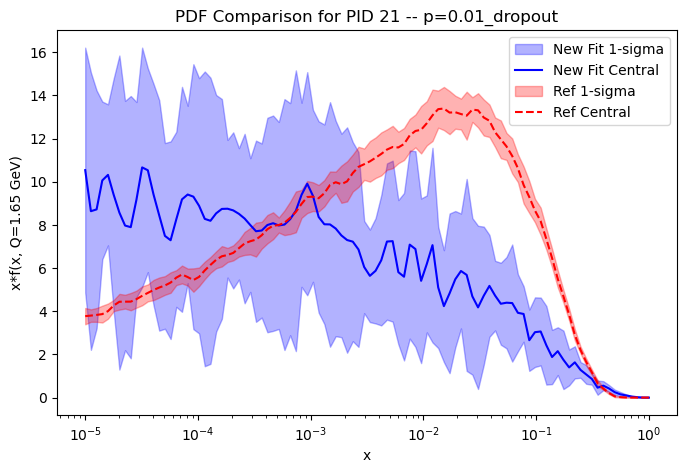

In [24]:
def get_stats(pdf_members, x_arr, q_val, flavor):
    # Evaluate xf(x, Q) across all replicas
    reps = np.array([[pdf.xfxQ(flavor, x, q_val) for x in x_arr] for pdf in pdf_members[1:]])
    
    # Extract central fit (member 0)
    central = np.array([pdf_members[0].xfxQ(flavor, x, q_val) for x in x_arr])
    
    # Calculate standard deviation from replicas
    std = np.std(reps, axis=0)
    return central, central - std, central + std

c_new, err_down_new, err_up_new = get_stats(new_fit, x_vals, Q, pid)
c_ref, err_down_ref, err_up_ref = get_stats(ref_fit, x_vals, Q, pid)

# Plotting
fig, ax = plt.subplots(figsize=(8,5))

# New Fit
ax.fill_between(x_vals, err_down_new, err_up_new, alpha=0.3, color='blue', label='New Fit 1-sigma')
ax.plot(x_vals, c_new, color='blue', label='New Fit Central')

# Reference Fit
ax.fill_between(x_vals, err_down_ref, err_up_ref, alpha=0.3, color='red', label='Ref 1-sigma')
ax.plot(x_vals, c_ref, color='red', linestyle='dashed', label='Ref Central')

ax.set_xscale('log')
ax.set_xlabel('x')
ax.set_ylabel(f'x*f(x, Q={Q} GeV)')
title = f'PDF Comparison for PID {pid} -- p={p_value}' if keywords is None else f'PDF Comparison for PID {pid} -- p={p_value}_{keywords}'
ax.set_title(title)
ax.legend()
plt.show()
fname = f'gluon_p{p_value}_Q{Q}' if keywords is None else f'gluon_p{p_value}_Q{Q}_{keywords}'
fig.savefig(f"/mnt/c/Users/daksh/nnpdf_reports/lhapdf_plots/{fname}.png")

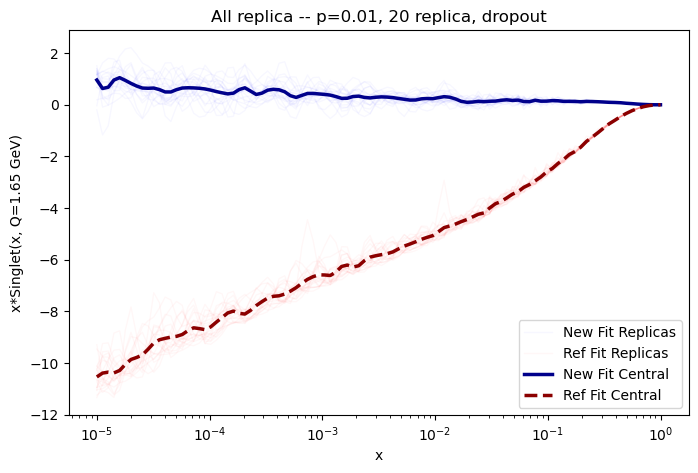

In [25]:
#x_vals = np.linspace(0,1,100)for linear scale
def get_xfx(pdf, x, Q, target):
    """Returns target PDF. 'target' can be a PID (flavor basis) or string (evolution basis)."""
    if isinstance(target, int):
        return pdf.xfxQ(target, x, Q)
    
    # Extract flavors for evolution basis
    u, ubar = pdf.xfxQ(2, x, Q), pdf.xfxQ(-2, x, Q)
    d, dbar = pdf.xfxQ(1, x, Q), pdf.xfxQ(-1, x, Q)
    s, sbar = pdf.xfxQ(3, x, Q), pdf.xfxQ(-3, x, Q)
    # add c, b, t as needed based on your Nf scheme
    
    if target == 'Singlet':
        return (u + ubar) + (d + dbar) + (s + sbar)
    elif target == 'T3':
        return (u + ubar) - (d + dbar)
    elif target == 'V3':
        return (u - ubar) - (d - dbar)

target_pdf = 'Singlet' # Change to PID (e.g., 21) for flavor basis

fig, ax = plt.subplots(figsize=(8, 5))

# Plot all replicas for New Fit
for i, pdf in enumerate(new_fit[1:]):
    y = [get_xfx(pdf, x, Q, target_pdf) for x in x_vals]
    ax.plot(x_vals, y, color='blue', alpha=0.03, lw=1, 
            label='New Fit Replicas' if i == 0 else "")

# Plot all replicas for Reference Fit
for i, pdf in enumerate(ref_fit[1:]):
    y = [get_xfx(pdf, x, Q, target_pdf) for x in x_vals]
    ax.plot(x_vals, y, color='red', alpha=0.03, lw=1, 
            label='Ref Fit Replicas' if i == 0 else "")
    
# Plot Central Fits (Member 0)
ax.plot(x_vals, [get_xfx(new_fit[0], x, Q, target_pdf) for x in x_vals], 
        color='darkblue', lw=2.5, label='New Fit Central')

ax.plot(x_vals, [get_xfx(ref_fit[0], x, Q, target_pdf) for x in x_vals], 
        color='darkred', lw=2.5, linestyle='--', label='Ref Fit Central')

ax.set_xscale('log')
ax.set_xlabel('x')
ax.set_ylabel(f'x*{target_pdf}(x, Q={Q} GeV)')
ax.legend()
title = f"All replica -- p={p_value}, {replica} replica" if keywords is None else f"All replica -- p={p_value}, {replica} replica, {keywords}"
ax.set_title(title)
plt.show()
fname = f"replica_p{p_value}_{replica}_Q{Q}" if keywords is None else f"replica_p{p_value}_{replica}_Q{Q}_{keywords}"
fig.savefig(f"/mnt/c/Users/daksh/nnpdf_reports/lhapdf_plots/{fname}.png")

In [15]:
# Check max values for each replica
for i, pdf in enumerate(new_fit):
    max_val = max([pdf.xfxQ(21, x, Q) for x in x_vals])
    if max_val > 50:
        print(f"Replica {i} is divergent. Max xg: {max_val}")

Replica 0 is divergent. Max xg: 319.35063139005024
Replica 1 is divergent. Max xg: 292.11525697678684
Replica 2 is divergent. Max xg: 330.67432050336436
Replica 3 is divergent. Max xg: 324.72791071495084
Replica 4 is divergent. Max xg: 332.7324843593043
Replica 5 is divergent. Max xg: 297.45088145549715
Replica 6 is divergent. Max xg: 353.0052008591662
Replica 7 is divergent. Max xg: 288.16996549380127
Replica 8 is divergent. Max xg: 353.0998666593176
Replica 9 is divergent. Max xg: 293.8481852989508
Replica 10 is divergent. Max xg: 313.6021134466049
Replica 11 is divergent. Max xg: 370.6062739865787
Replica 12 is divergent. Max xg: 372.48585393855063
Replica 13 is divergent. Max xg: 339.1011004132153
Replica 14 is divergent. Max xg: 311.71682149295367
Replica 15 is divergent. Max xg: 288.0767185282029
Replica 16 is divergent. Max xg: 305.2142054102138
Replica 17 is divergent. Max xg: 290.03764230092463
Replica 18 is divergent. Max xg: 306.051747592394
Replica 19 is divergent. Max xg: 

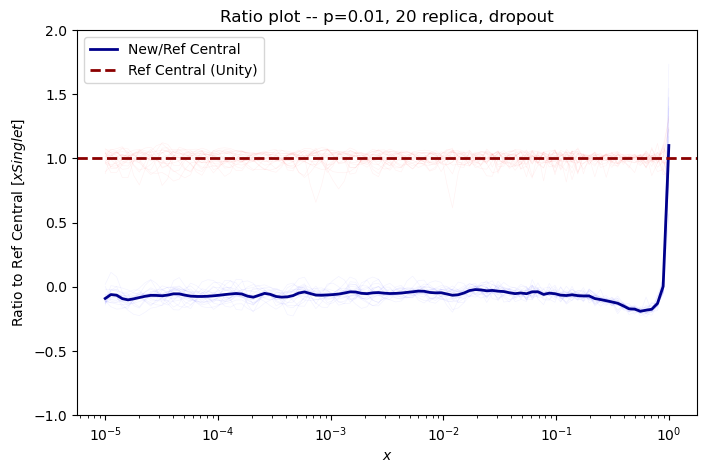

In [26]:
def get_pdf_val(pdf, x, Q, flavor):
    """Handles PIDs (int) or Evolution Basis (str)."""
    if isinstance(flavor, int):
        return pdf.xfxQ(flavor, x, Q)
    
    # Evolution Basis Definitions
    u, ubar = pdf.xfxQ(2, x, Q), pdf.xfxQ(-2, x, Q)
    d, dbar = pdf.xfxQ(1, x, Q), pdf.xfxQ(-1, x, Q)
    s, sbar = pdf.xfxQ(3, x, Q), pdf.xfxQ(-3, x, Q)
    
    basis = {
        'Singlet': (u + ubar) + (d + dbar) + (s + sbar),
        'V': (u - ubar) + (d - dbar) + (s - sbar),
        'T3': (u + ubar) - (d + dbar),
        'V3': (u - ubar) - (d - dbar)
    }
    return basis[flavor]

# Target can be PID (e.g., 21) or Basis string (e.g., 'Singlet')
target = 'Singlet'

# Calculate Reference Central for denominator
ref_central = np.array([get_pdf_val(ref_fit[0], x, Q, target) for x in x_vals])

fig, ax = plt.subplots(figsize=(8, 5))

# Plot New Fit Replicas (Ratio)
for i, pdf in enumerate(new_fit[1:]):
    vals = np.array([get_pdf_val(pdf, x, Q, target) for x in x_vals])
    ax.plot(x_vals, vals / ref_central, color='blue', alpha=0.05, lw=0.5)

# Plot Reference Fit Replicas (Ratio)
for i, pdf in enumerate(ref_fit[1:]):
    vals = np.array([get_pdf_val(pdf, x, Q, target) for x in x_vals])
    ax.plot(x_vals, vals / ref_central, color='red', alpha=0.05, lw=0.5)

# Plot Central Ratios
new_central_vals = np.array([get_pdf_val(new_fit[0], x, Q, target) for x in x_vals])
ax.plot(x_vals, new_central_vals / ref_central, color='darkblue', lw=2, label='New/Ref Central')
ax.axhline(1.0, color='darkred', lw=2, linestyle='--', label='Ref Central (Unity)')

ax.set_xscale('log')
ax.set_ylabel(f'Ratio to Ref Central [$x{target}$]')
ax.set_xlabel('$x$')
ax.set_ylim(-1, 2) # Adjust this if your fit is diverging (e.g., 0 to 100)
ax.legend()
title = f"Ratio plot -- p={p_value}, {replica} replica" if keywords is None else f"Ratio plot -- p={p_value}, {replica} replica, {keywords}"
ax.set_title(title)
plt.show()
fname = f"ratio_p{p_value}_{replica}_Q{Q}" if keywords is None else f"ratio_p{p_value}_{replica}_Q{Q}_{keywords}"
fig.savefig(f"/mnt/c/Users/daksh/nnpdf_reports/lhapdf_plots/{fname}.png")